In [1]:
import sys
import os

path = os.path.abspath(os.path.join(os.getcwd(), "../"))
sys.path.insert(0, path)
from tdaphantom.tdaphantom import Phantom

In [2]:
from ripser import ripser
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
PRECOMPUTED_DIR = "./precomputed"

In [3]:
def _make_disk(n=2000, seed=0):
    rng = np.random.default_rng(seed)
    pts = []
    while len(pts) < n:
        b = rng.uniform(-1, 1, (n * 4, 2))
        pts.append(b[np.linalg.norm(b, axis=1) <= 1.0])
    return np.vstack(pts)[:n]


def _make_circle(n=2000, noise=0.03, seed=1):
    rng   = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    pts   = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    return pts + rng.normal(0, noise, pts.shape)


def _make_torus(n=2000, R=5.0, r=3.0, seed=2):
    rng   = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    phi_list = []
    while len(phi_list) < n:
        phi_c = rng.uniform(0, 2 * np.pi, n * 2)
        w     = (R + r * np.cos(phi_c)) / (R + r)
        phi_list.append(phi_c[rng.uniform(0, 1, len(phi_c)) < w])
    phi = np.concatenate(phi_list)[:n]
    x   = (R + r * np.cos(phi)) * np.cos(theta)
    y   = (R + r * np.cos(phi)) * np.sin(theta)
    z   =  r * np.sin(phi)
    return np.stack([x, y, z], axis=1)



In [4]:

pc_disk   = _make_disk()
pc_circle = _make_circle()
pc_torus  = _make_torus()

phantom_disk   = Phantom(pc_disk)
phantom_circle = Phantom(pc_circle)
phantom_torus  = Phantom(pc_torus)

print(phantom_disk)
print(phantom_circle)
print(phantom_torus)

Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[], diagram_sizes={})
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[], diagram_sizes={})
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[], diagram_sizes={})


In [5]:
phantom_disk.calculate_dgms_from_point_cloud(k=1)
phantom_circle.calculate_dgms_from_point_cloud(k=1)
phantom_torus.calculate_dgms_from_point_cloud(k=1)


print(f"Disk   — H_1 bars: {len(phantom_disk.dgms[1])}")
print(f"Circle — H_1 bars: {len(phantom_circle.dgms[1])}")
print(f"Torus  — H_1 bars: {len(phantom_torus.dgms[1])}")

print(phantom_disk)
print(phantom_circle)
print(phantom_torus)

Disk   — H_1 bars: 517
Circle — H_1 bars: 392
Torus  — H_1 bars: 530
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[0, 1], diagram_sizes={0: 2000, 1: 517})
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[0, 1], diagram_sizes={0: 2000, 1: 392})
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[0, 1], diagram_sizes={0: 2000, 1: 530})


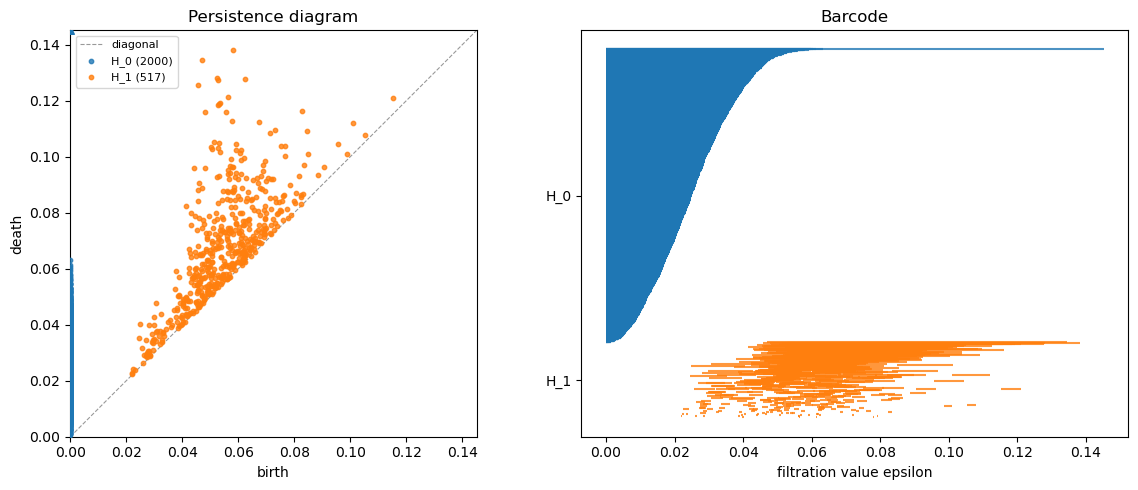

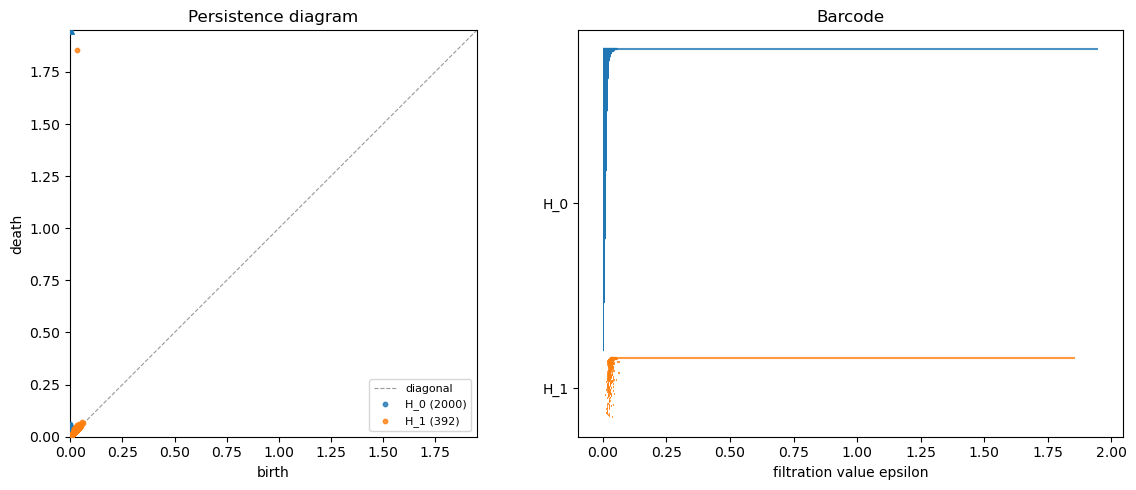

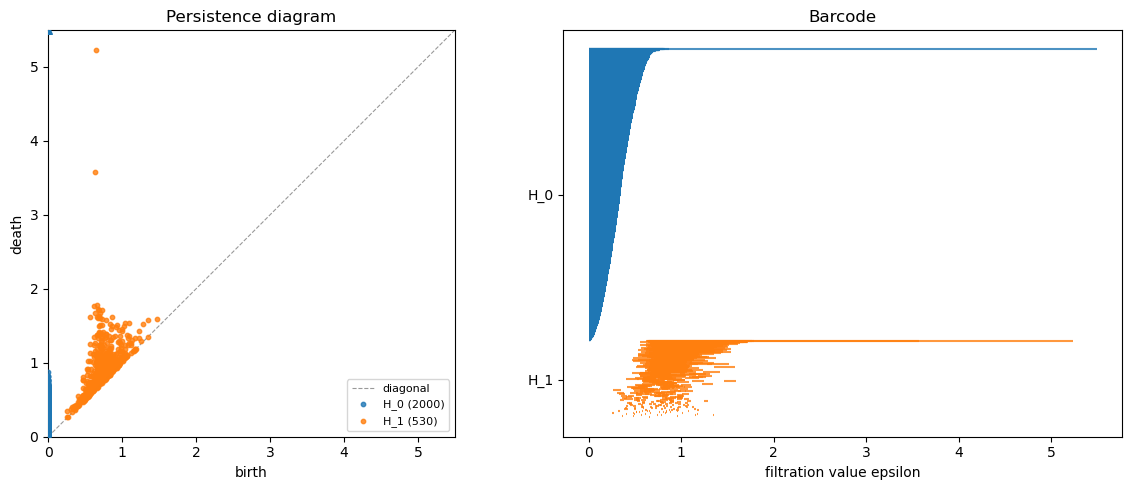

In [6]:
phantom_disk.display_dgms()
phantom_circle.display_dgms()
phantom_torus.display_dgms()

In [7]:
alpha = 0.01
method = ["bottleneck"]
results_disk   = phantom_disk.hypothesis_test(alpha=alpha,methods=method)
results_circle = phantom_circle.hypothesis_test(alpha=alpha,methods=method)
results_torus  = phantom_torus.hypothesis_test(alpha=alpha,methods=method)

phantom_disk.display_results()
phantom_circle.display_results()
phantom_torus.display_results()

N: 1000
0/1000, 0.0%
1/1000, 0.1%
2/1000, 0.2%
3/1000, 0.3%
4/1000, 0.4%
5/1000, 0.5%
6/1000, 0.6%
7/1000, 0.7%
8/1000, 0.8%
9/1000, 0.9%
10/1000, 1.0%
11/1000, 1.1%
12/1000, 1.2%
13/1000, 1.3%
14/1000, 1.4%
15/1000, 1.5%
16/1000, 1.6%
17/1000, 1.7%
18/1000, 1.8%
19/1000, 1.9%
20/1000, 2.0%
21/1000, 2.1%
22/1000, 2.2%
23/1000, 2.3%
24/1000, 2.4%
25/1000, 2.5%
26/1000, 2.6%
27/1000, 2.7%
28/1000, 2.8%
29/1000, 2.9%
30/1000, 3.0%
31/1000, 3.1%
32/1000, 3.2%
33/1000, 3.3%
34/1000, 3.4%
35/1000, 3.5%
36/1000, 3.6%
37/1000, 3.7%
38/1000, 3.8%
39/1000, 3.9%
40/1000, 4.0%
41/1000, 4.1%
42/1000, 4.2%
43/1000, 4.3%
44/1000, 4.4%
45/1000, 4.5%
46/1000, 4.6%
47/1000, 4.7%
48/1000, 4.8%
49/1000, 4.9%
50/1000, 5.0%
51/1000, 5.1%
52/1000, 5.2%
53/1000, 5.3%
54/1000, 5.4%
55/1000, 5.5%
56/1000, 5.6%
57/1000, 5.7%
58/1000, 5.8%
59/1000, 5.9%
60/1000, 6.0%
61/1000, 6.1%
62/1000, 6.2%
63/1000, 6.3%
64/1000, 6.4%
65/1000, 6.5%
66/1000, 6.6%
67/1000, 6.7%
68/1000, 6.8%
69/1000, 6.9%
70/1000, 7.0%
71/1000,

NameError: name 'T_j_array' is not defined